# 🔬 PUF Fotónica SmartLight — Cuaderno de Laboratorio
**TFM · Oxel Arnal Martínez · ITEAM/PRL · UPV · 2025**

---
Ejecuta las celdas **en orden**, de arriba a abajo.

Cuando cambies el setup físico del laboratorio para medir un nuevo puerto,
cambia `INPORT` en la **Celda 1** y vuelve a ejecutar desde la **Celda 6**.

| Celda | Qué hace | ¿Cuántas veces? |
|-------|----------|-----------------|
| 0 | Imports y funciones auxiliares | 1 vez |
| 1 | Parámetros y rutas | 1 vez |
| 2 | Conectar chip y láser | 1 vez |
| 3 | Fases pasivas φ₀ | 1 vez |
| 4 | TBUs dinámicas y canales MEDA | 1 vez |
| 5 | Generar retos (corrientes mA) | 1 vez |
| 6 | Verificar ruta del puerto actual | Cada puerto |
| 7 | **MEDIR — bucle de retos** | Cada puerto |
| 8 | Comprobar reproducibilidad | Cada puerto |
| 9 | Calcular métricas PUF | Al final |
| 10 | Desconectar el chip | Al final |

## Celda 0 — Imports y funciones auxiliares
Ejecutar una sola vez al abrir el cuaderno.

In [1]:
import json, math, random, hashlib, time, pathlib
from pathlib import Path
import numpy as np
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from smartlight import Smartlight
import yaml
import warnings
import logging

# ── Función: firma Lehmer-Gray ────────────────────────────────────────────
def lehmer_gray_signature(powers_dict, ports):
    """
    Convierte un vector de potencias en una firma binaria.
      1. Ordena los puertos por potencia descendente → permutación
      2. Calcula el código de Lehmer de esa permutación
      3. Codifica cada dígito Lehmer en código Gray
    Para 27 puertos de salida → ~3052 bits.
    """
    N = len(ports)
    sorted_ports = sorted(ports, key=lambda p: powers_dict.get(p, 0.0), reverse=True)
    perm         = [ports.index(p) for p in sorted_ports]
    used, lehmer = [False] * N, []
    for val in perm:
        lehmer.append(sum(1 for j in range(val) if not used[j]))
        used[val] = True
    bits = []
    for i, digit in enumerate(lehmer):
        max_val = N - i
        n_bits  = max(1, math.ceil(math.log2(max_val + 1))) if max_val > 1 else 1
        gray    = digit ^ (digit >> 1)
        for b in range(n_bits - 1, -1, -1):
            bits.append((gray >> b) & 1)
    return bits

def hamming_distance(s1, s2):
    n = min(len(s1), len(s2))
    return sum(a != b for a, b in zip(s1[:n], s2[:n])) / n if n > 0 else 0.0

def sha256_bits(bits):
    n   = len(bits)
    val = int(''.join(str(b) for b in bits), 2)
    raw = val.to_bytes((n + 7) // 8, 'big')
    return [int(x) for byte in hashlib.sha256(raw).digest() for x in f'{byte:08b}']

print('✓ Imports y funciones cargados.')

✓ Imports y funciones cargados.


## Celda 1 — Parámetros y rutas
Ajusta los valores de esta celda antes de empezar.

> **Cuando cambies de puerto:** modifica solo `INPORT` y vuelve a ejecutar desde la Celda 6.

In [ ]:
# ── Ajustar antes de cada sesión ─────────────────────────────────────────
CONFIG_PATH      = pathlib.Path('logging.yaml')  # fichero del chip
LASER_POWER_DBM  = -3.0    # confirmar con el técnico
LASER_WAVELENGTH = 1550.0  # confirmar con el técnico (nm)
I_MAX_MA         = 2   # corriente máxima por heater — confirmar con el técnico
N_CHALLENGES     = 10     # retos por puerto
SEED             = 42      # no cambiar entre sesiones

# CARGAMOS ARCHIVO DE CONFIGURACIÓN

config = yaml.safe_load(Path("logging.yaml").read_text())
logging.config.dictConfig(config)

# ── Puerto de entrada activo ──────────────────────────────────────────────
# Cambia este número cada vez que cambies el setup físico del laboratorio.
INPORT = 3

# ── Puertos físicamente accesibles (los índices 22-33 están bloqueados) ───
ACTIVE_PORTS = list(range(0, 22)) + list(range(34, 40))  # 28 puertos

# ── Directorio de resultados ──────────────────────────────────────────────
RESULTS_DIR = pathlib.Path('resultados_v2')
RESULTS_DIR.mkdir(exist_ok=True)

# ── Rutas maestras del Anillo Isotrópico ─────────────────────────────────
# Para cada puerto: lista de (ID_TBU, estado)
#   estado = 'x' (CROSS) | '=' (BAR) | float (coupling factor)
RUTAS = {
    0:  [(0,'x'),(6,'x'),(10,'x'),(16,'x'),(21,'x'),(26,'x'),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    1:  [(0,'='),(6,'x'),(10,'x'),(16,'x'),(21,'x'),(26,'x'),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    2:  [(9,'x'),(10,'='),(16,'x'),(21,'x'),(26,'x'),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    3:  [(15,'x'),(19,'='),(20,'x'),(21,'='),(26,'x'),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    4:  [(15,'x'),(9,'='),(10,'='),(16,'x'),(21,'x'),(26,'x'),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    5:  [(19,'x'),(20,'x'),(21,'='),(26,'x'),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    6:  [(28,'x'),(29,'x'),
         (30,'x'),(31,1-1/6),(36,1-1/5),(41,1-1/4),(40,1-1/3),(35,1-1/2)],
    7:  [(34,'x'),(38,'='),(39,'x'),
         (35,'x'),(30,1-1/6),(31,1-1/5),(36,1-1/4),(41,1-1/3),(40,1-1/2)],
    8:  [(34,'x'),(28,'='),(29,'x'),
         (30,'x'),(31,1-1/6),(36,1-1/5),(41,1-1/4),(40,1-1/3),(35,1-1/2)],
    9:  [(38,'x'),(39,'x'),
         (35,'x'),(30,1-1/6),(31,1-1/5),(36,1-1/4),(41,1-1/3),(40,1-1/2)],
    10: [(47,'='),(44,'x'),(39,'x'),
         (35,'x'),(30,1-1/6),(31,1-1/5),(36,1-1/4),(41,1-1/3),(40,1-1/2)],
    11: [(53,'x'),(57,'='),(58,'='),(54,'x'),(49,'x'),(45,'x'),
         (40,'x'),(35,1-1/6),(30,1-1/5),(31,1-1/4),(36,1-1/3),(41,1-1/2)],
    12: [(53,'x'),(47,'='),(48,'x'),(49,'='),(45,'x'),
         (40,'x'),(35,1-1/6),(30,1-1/5),(31,1-1/4),(36,1-1/3),(41,1-1/2)],
    13: [(57,'x'),(58,'='),(54,'x'),(49,'x'),(45,'x'),
         (40,'x'),(35,1-1/6),(30,1-1/5),(31,1-1/4),(36,1-1/3),(41,1-1/2)],
    14: [(66,'='),(63,'x'),(58,'x'),(54,'x'),(49,'x'),(45,'x'),
         (40,'x'),(35,1-1/6),(30,1-1/5),(31,1-1/4),(36,1-1/3),(41,1-1/2)],
    15: [(66,'x'),(63,'x'),(58,'x'),(54,'x'),(49,'x'),(45,'x'),
         (40,'x'),(35,1-1/6),(30,1-1/5),(31,1-1/4),(36,1-1/3),(41,1-1/2)],
    16: [(67,'x'),(63,'='),(58,'x'),(54,'x'),(49,'x'),(45,'x'),
         (40,'x'),(35,1-1/6),(30,1-1/5),(31,1-1/4),(36,1-1/3),(41,1-1/2)],
    17: [(68,'x'),(64,'='),(59,'x'),(54,'='),(49,'x'),(45,'x'),
         (40,'x'),(35,1-1/6),(30,1-1/5),(31,1-1/4),(36,1-1/3),(41,1-1/2)],
    18: [(69,'x'),(64,'x'),(59,'x'),(54,'='),(49,'x'),(45,'x'),
         (40,'x'),(35,1-1/6),(30,1-1/5),(31,1-1/4),(36,1-1/3),(41,1-1/2)],
    19: [(70,'x'),(65,'='),(61,'x'),(55,'x'),(50,'x'),(45,'x'),
         (40,'x'),(35,1-1/6),(30,1-1/5),(31,1-1/4),(36,1-1/3),(41,1-1/2)],
    20: [(71,'x'),(65,'x'),(61,'x'),(55,'x'),(50,'x'),(45,'x'),
         (40,'x'),(35,1-1/6),(30,1-1/5),(31,1-1/4),(36,1-1/3),(41,1-1/2)],
    21: [(71,'='),(65,'x'),(61,'x'),(55,'x'),(50,'x'),(45,'x'),
         (40,'x'),(35,1-1/6),(30,1-1/5),(31,1-1/4),(36,1-1/3),(41,1-1/2)],
    22: [(62,'x'),(61,'='),(55,'x'),(50,'x'),(45,'x'),
         (40,'x'),(35,1-1/6),(30,1-1/5),(31,1-1/4),(36,1-1/3),(41,1-1/2)],
    23: [(56,'x'),(52,'='),(51,'x'),(50,'='),(45,'x'),
         (40,'x'),(35,1-1/6),(30,1-1/5),(31,1-1/4),(36,1-1/3),(41,1-1/2)],
    24: [(56,'x'),(62,'='),(61,'='),(55,'x'),(50,'x'),(45,'x'),
         (40,'x'),(35,1-1/6),(30,1-1/5),(31,1-1/4),(36,1-1/3),(41,1-1/2)],
    25: [(52,'x'),(51,'x'),(50,'='),(45,'x'),
         (40,'x'),(35,1-1/6),(30,1-1/5),(31,1-1/4),(36,1-1/3),(41,1-1/2)],
    26: [(43,'x'),(42,'x'),
         (41,'x'),(40,1-1/6),(35,1-1/5),(30,1-1/4),(31,1-1/3),(36,1-1/2)],
    27: [(37,'x'),(33,'='),(32,'x'),
         (36,'x'),(41,1-1/6),(40,1-1/5),(35,1-1/4),(30,1-1/3),(31,1-1/2)],
    28: [(37,'x'),(43,'='),(42,'x'),
         (41,'x'),(40,1-1/6),(35,1-1/5),(30,1-1/4),(31,1-1/3),(36,1-1/2)],
    29: [(33,'x'),(32,'x'),
         (36,'x'),(41,1-1/6),(40,1-1/5),(35,1-1/4),(30,1-1/3),(31,1-1/2)],
    30: [(24,'='),(27,'x'),(32,'x'),
         (36,'x'),(41,1-1/6),(40,1-1/5),(35,1-1/4),(30,1-1/3),(31,1-1/2)],
    31: [(18,'x'),(14,'='),(13,'='),(17,'x'),(22,'x'),(26,'x'),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    32: [(18,'x'),(24,'x'),(27,'x'),(32,'x'),
         (36,'x'),(41,1-1/6),(40,1-1/5),(35,1-1/4),(30,1-1/3),(31,1-1/2)],
    33: [(14,'x'),(13,'='),(17,'x'),(22,'x'),(26,'x'),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    34: [(5,'='),(8,'x'),(13,'x'),(17,'x'),(22,'x'),(26,'x'),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    35: [(5,'x'),(8,'x'),(13,'x'),(17,'x'),(22,'x'),(26,'x'),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    36: [(4,'x'),(8,'='),(13,'x'),(17,'x'),(22,'x'),(26,'x'),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    37: [(3,'x'),(7,'='),(12,'x'),(17,'='),(22,'x'),(26,'x'),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    38: [(2,'x'),(7,'='),(11,'x'),(16,'='),(21,'x'),(26,'x'),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    39: [(1,'x'),(6,'='),(10,'x'),(16,'x'),(21,'x'),(26,'x'),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
}

ALL_ROUTE_PUCS = sorted({tbu for ruta in RUTAS.values() for (tbu, _) in ruta})
outports       = [p for p in ACTIVE_PORTS if p != INPORT]

print(f'Puerto activo:      {INPORT}')
print(f'Puertos de salida:  {len(outports)}')
print(f'TBUs en rutas:      {len(ALL_ROUTE_PUCS)}')
print(f'Resultados en:      {RESULTS_DIR}/')
print(f'\nRuta del puerto {INPORT}:')
for tbu, estado in RUTAS[INPORT]:
    if isinstance(estado, str):
        print(f'  TBU {tbu:>3}  {"CROSS" if estado == "x" else "BAR":>6}  (gateway)')
    else:
        print(f'  TBU {tbu:>3}  {estado:>6.4f}  (anillo)')

Puerto activo:      3
Puertos de salida:  27
TBUs en rutas:      68
Resultados en:      resultados/

Ruta del puerto 3:
  TBU  15   CROSS  (gateway)
  TBU  19     BAR  (gateway)
  TBU  20   CROSS  (gateway)
  TBU  21     BAR  (gateway)
  TBU  26   CROSS  (gateway)
  TBU  31   CROSS  (gateway)
  TBU  36  0.8333  (anillo)
  TBU  41  0.8000  (anillo)
  TBU  40  0.7500  (anillo)
  TBU  35  0.6667  (anillo)
  TBU  30  0.5000  (anillo)


## Celda 2 — Conectar el chip y configurar el láser
Ejecutar **una sola vez** al inicio de la sesión.

> `reset_mesh()` pone todos los PUCs a corriente 0 → estado limpio, solo φ₀ activa.

In [78]:
sl.disconnect()

In [4]:
sl = Smartlight()
print(f'Chip conectado  |  Simulación: {sl.get_sim_status()}')



# Estado limpio: todos los PUCs a corriente 0
# → cada TBU opera solo bajo su fase pasiva de fabricación φ₀
sl.reset_mesh()
print('reset_mesh() — todos los PUCs en φ₀ puro')


Chip conectado  |  Simulación: False
reset_mesh() — todos los PUCs en φ₀ puro


## Celda 3 — Leer las fases pasivas del chip (φ₀)
Las fases pasivas son el **ADN de fabricación** del chip. Son únicas e irrepetibles.
Las guardamos para referencia pero **no las usamos para calibrar nada**.

In [14]:
passive_phases = sl.get_puc_passive_phases()
# passive_phases = {puc_id: fase_en_radianes}

print(f'Fases pasivas leídas: {len(passive_phases)} PUCs')
print()
print(f'{"PUC":>5}  {"φ₀ (rad)":>10}')
print('-' * 20)
for puc_id, phi in sorted(passive_phases.items()):
    print(f'{puc_id:>5}  {phi:>10.4f}')

with open(RESULTS_DIR / 'passive_phases.json', 'w') as f:
    json.dump({str(k): v for k, v in passive_phases.items()}, f, indent=2)
print(f'\nGuardado en {RESULTS_DIR}/passive_phases.json')

Fases pasivas leídas: 72 PUCs

  PUC    φ₀ (rad)
--------------------
    0      6.2832
    1      1.1649
    2      5.9883
    3      5.6633
    4      2.5068
    5      3.7217
    6      5.6645
    7      1.5799
    8      0.0501
    9      1.2404
   10      0.7351
   11      0.7654
   12      5.9203
   13      2.1409
   14      1.9681
   15      4.5234
   16      0.2819
   17      5.6514
   18      5.8597
   19      1.2376
   20      6.2077
   21      0.9829
   22      4.6407
   23      0.9566
   24      2.8112
   25      5.0449
   26      2.2207
   27      0.8443
   28      0.5158
   29      1.7523
   30      6.2832
   31      5.0592
   32      3.7785
   33      2.4613
   34      5.0327
   35      2.8530
   36      0.5666
   37      5.7939
   38      1.2032
   39      0.8102
   40      0.4695
   41      4.0035
   42      0.7564
   43      2.8298
   44      0.8093
   45      3.5141
   46      1.3991
   47      2.0017
   48      1.4080
   49      6.0009
   50      6.2832
   51      1

In [107]:
import time
import numpy as np

# ── TEST PUC 15 — barrido de fases ────────────────────────────────────
# Primero programamos la ruta del puerto 3
sl.reset_mesh()
sl.interconnect(puc_state_list=RUTAS[INPORT])

OUTPORT_TEST = 4
FASE_STEP    = np.pi / 8
fases        = np.arange(0, 2*np.pi + FASE_STEP/2, FASE_STEP)

print(f'Puerto entrada: {INPORT}')
print(f'Puerto salida:  {OUTPORT_TEST}')
print(f'PUC test:       15 (gateway CROSS en la ruta)')
print()
print(f'{"Fase (°)":>10}  {"Potencia (dBm)":>15}')
print('-' * 28)

for fase in fases:
    # Reprogramar ruta y luego setear fase en PUC 15
    sl.reset_puc(pucs_id=list(route_pucs_inport))
    sl.interconnect(puc_state_list=RUTAS[INPORT])
    sl.set_driven_phases({15: [fase, 0.0]}, compensate_passive_phase=False)
    time.sleep(0.3)
    powers   = sl.get_output_power(inport=INPORT, outport=[OUTPORT_TEST])
    potencia = powers[OUTPORT_TEST]
    print(f'{np.degrees(fase):>10.1f}  {potencia:>15.4f}')

# Restaurar
sl.reset_puc(pucs_id=list(route_pucs_inport))
sl.interconnect(puc_state_list=RUTAS[INPORT])
print('\n✓ Ruta restaurada')

Puerto entrada: 3
Puerto salida:  4
PUC test:       15 (gateway CROSS en la ruta)

  Fase (°)   Potencia (dBm)
----------------------------
       0.0          -3.1350
      22.5          -4.8641
      45.0          -7.4708
      67.5         -11.6977
      90.0         -20.9840
     112.5         -20.7912
     135.0         -11.6498
     157.5          -7.4539
     180.0          -4.8691
     202.5          -3.1597
     225.0          -2.7678
     247.5          -2.7678
     270.0          -2.7678
     292.5          -2.7678
     315.0          -2.7678
     337.5          -2.7678
     360.0          -3.0724

✓ Ruta restaurada


In [109]:
import time
import numpy as np

# ── TEST COUPLING FACTOR TBU 36 ───────────────────────────────────────
# TBU 36 es la primera del anillo en la ruta del puerto 3
# coupling factor = fracción de potencia que va al puerto cruzado

OUTPORT_TEST = 4   # puerto de salida a monitorizar

coupling_factors = [0.0, 1/6, 1/4, 1/3, 0.5, 2/3, 3/4, 5/6, 1.0]

print(f'Puerto entrada: {INPORT}')
print(f'Puerto salida:  {OUTPORT_TEST}')
print(f'PUC test:       36 (primer TBU del anillo)')
print()
print(f'{"CF":>8}  {"Potencia (dBm)":>15}')
print('-' * 26)

for cf in coupling_factors:
    # Reprogramar ruta con coupling factor modificado en TBU 36
    ruta_test = [
        (15,cf),(19,'='),(20,'x'),(21,'='),(26,'x'),
        (31,'x'),
        (36, 1-1/6),          # ← variar este
        (41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)
    ]
    sl.reset_puc(pucs_id=list(route_pucs_inport))
    sl.interconnect(puc_state_list=ruta_test)
    time.sleep(0.3)

    powers   = sl.get_output_power(inport=INPORT, outport=outports)
    potencia = powers.get(OUTPORT_TEST, -60.0)
    print(f'{cf:>8.4f}  {potencia:>15.4f}')

# Restaurar ruta original
sl.reset_puc(pucs_id=list(route_pucs_inport))
sl.interconnect(puc_state_list=RUTAS[INPORT])
print('\n✓ Ruta restaurada')

Puerto entrada: 3
Puerto salida:  4
PUC test:       36 (primer TBU del anillo)

      CF   Potencia (dBm)
--------------------------
  0.0000          -2.7678
  0.1667          -2.7678
  0.2500          -2.7678
  0.3333          -2.7678
  0.5000          -3.9855
  0.6667          -5.7836
  0.7500          -7.0531
  0.8333          -8.8485
  1.0000         -34.5683

✓ Ruta restaurada


## Celda 4 — TBUs dinámicas y canales MEDA
Las **TBUs dinámicas** son las que nunca se calibran — su respuesta lleva el fingerprint del chip.

El MEDA controla los heaters por **canales**, no por PUC IDs.
Cada TBU tiene 2 heaters (brazo up y brazo down) → 2 canales por TBU.

In [5]:

all_pucs = set(range(72))

# TBUs dinámicas = todas menos las de la ruta de este puerto
route_pucs_inport = {puc for puc, _ in RUTAS[INPORT]}
dynamic_pucs      = sorted(all_pucs - route_pucs_inport)

print(f'PUCs totales:                   72')
print(f'TBUs de ruta (puerto {INPORT}):     {len(route_pucs_inport)}  → {sorted(route_pucs_inport)}')
print(f'TBUs dinámicas (entropía PUF):  {len(dynamic_pucs)}')
print(f'IDs dinámicas: {dynamic_pucs}')

# Mapa de canales MEDA
meda     = sl.get_meda()
wma      = sl.get_wma()
full_map = meda.get_mapping()

channel_map = {puc: full_map[puc] for puc in dynamic_pucs if puc in full_map}
missing     = [puc for puc in dynamic_pucs if puc not in full_map]
if missing:
    print(f'\nAVISO: TBUs sin mapeo MEDA (se excluyen): {missing}')

print(f'\nMapeo MEDA de TBUs dinámicas (puerto {INPORT}):')
print(f'{"PUC":>5}  {"canal_up":>9}  {"canal_down":>10}')
print('-' * 30)
for puc, (cu, cd) in channel_map.items():
    print(f'{puc:>5}  {cu:>9}  {cd:>10}')

all_dynamic_channels = [ch for canales in channel_map.values() for ch in canales]
print(f'\nCanales dinámicos totales: {len(all_dynamic_channels)} '
      f'({len(channel_map)} TBUs × 2 heaters)')

PUCs totales:                   72
TBUs de ruta (puerto 3):     11  → [15, 19, 20, 21, 26, 30, 31, 35, 36, 40, 41]
TBUs dinámicas (entropía PUF):  61
IDs dinámicas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 22, 23, 24, 25, 27, 28, 29, 32, 33, 34, 37, 38, 39, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]

Mapeo MEDA de TBUs dinámicas (puerto 3):
  PUC   canal_up  canal_down
------------------------------
    0        160         163
    1        161         162
    2        164         165
    3        309         314
    4        313         316
    5        317         318
    6        166         169
    7        301         310
    8        305         312
    9        168         173
   10        170         177
   11        172         181
   12        289         304
   13        293         306
   14        297         308
   16        176         189
   17        281         300
   18

## Celda 5 — Generar los retos
Un reto = `{canal_meda: corriente_mA}` para todos los canales dinámicos.

Las corrientes se aplican **directamente al MEDA sin ninguna conversión**.
La librería no calcula fases — manda los mA al driver del heater.

$$\varphi_{\text{total}} = \varphi_0 + \Delta\varphi(I_{\text{reto}})$$

El `SEED` fijo garantiza que los retos son siempre los mismos números.

In [ ]:
# ── PARÁMETROS DE FASE ────────────────────────────────────────────────
FASE_MAX = 2 * np.pi   # rad — barrido completo
SEED     = 42
N_CHALLENGES     = 1000
rng        = random.Random(SEED+INPORT)
challenges = [
    {puc: [round(rng.uniform(0.0, FASE_MAX), 4), 0.0]
     for puc in dynamic_pucs}
    for _ in range(N_CHALLENGES)
]

print(f'Retos generados:     {len(challenges)}')
print(f'PUCs dinámicas/reto: {len(challenges[0])}')
print(f'Rango de fases:      [0.0, 2π] rad')
print()
print('Ejemplo — reto 0 (primeros 6 PUCs):')
print(f'{"PUC":>5}  {"fase_up (rad)":>14}  {"fase_down (rad)":>16}')
print('-' * 38)
for puc, fases in list(challenges[0].items())[:6]:
    print(f'{puc:>5}  {fases[0]:>14.4f}  {fases[1]:>16.4f}')

with open(RESULTS_DIR / 'challenges.json', 'w') as f:
    json.dump([{str(k): v for k, v in ch.items()} for ch in challenges], f, indent=2)
print(f'\nRetos guardados en {RESULTS_DIR}/challenges.json')

Retos generados:     1000
PUCs dinámicas/reto: 61
Rango de fases:      [0.0, 2π] rad

Ejemplo — reto 0 (primeros 6 PUCs):
  PUC   fase_up (rad)   fase_down (rad)
--------------------------------------
    0          4.0176            0.0000
    1          0.1571            0.0000
    2          1.7281            0.0000
    3          1.4025            0.0000
    4          4.6274            0.0000
    5          4.2518            0.0000

Retos guardados en resultados/challenges.json


In [494]:
import random
import numpy as np
import json
import pathlib

# ── PARÁMETROS ────────────────────────────────────────────────────────
FASE_MAX     = 2 * np.pi
SEED         = 44
N_CHALLENGES = 500
ACTIVE_PORTS = list(range(0, 22)) + list(range(34, 40))

RETOS_DIR = pathlib.Path('retos_v6')
RETOS_DIR.mkdir(exist_ok=True)

# ── RUTAS (copiar de Celda 1) ─────────────────────────────────────────
RUTAS = {
    0:  [(0,'x'),(6,'x'),(10,'x'),(16,'x'),(21,'x'),(26,'x'),
         (31,'x'),(36,1/6),(41,1/5),(40,1/4),(35,1/3),(30,1/2)],
    1:  [(0,'='),(6,'x'),(10,'x'),(16,'x'),(21,'x'),(26,'x'),
         (31,'x'),(36,1/6),(41,1/5),(40,1/4),(35,1/3),(30,1/2)],
    2:  [(9,'x'),(10,'='),(16,'x'),(21,'x'),(26,'x'),
         (31,'x'),(36,1/6),(41,1/5),(40,1/4),(35,1/3),(30,1/2)],
    3:  [(15,'x'),(19,'='),(20,'x'),(21,'='),(26,'x'),
         (31,'x'),(36,1/6),(41,1/5),(40,1/4),(35,1/3),(30,1/2)],
    4:  [(15,'x'),(9,'='),(10,'='),(16,'x'),(21,'x'),(26,'x'),
         (31,'x'),(36,1/6),(41,1/5),(40,1/4),(35,1/3),(30,1/2)],
    5:  [(19,'x'),(20,'x'),(21,'='),(26,'x'),
         (31,'x'),(36,1/6),(41,1/5),(40,1/4),(35,1/3),(30,1/2)],
    6:  [(28,'x'),(29,'x'),
         (30,'x'),(31,1/6),(36,1/5),(41,1/4),(40,1/3),(35,1/2)],
    7:  [(34,'x'),(38,'='),(39,'x'),
         (35,'x'),(30,1/6),(31,1/5),(36,1/4),(41,1/3),(40,1/2)],
    8:  [(34,'x'),(28,'='),(29,'x'),
         (30,'x'),(31,1/6),(36,1/5),(41,1/4),(40,1/3),(35,1/2)],
    9:  [(38,'x'),(39,'x'),
         (35,'x'),(30,1/6),(31,1/5),(36,1/4),(41,1/3),(40,1/2)],
    10: [(47,'='),(44,'x'),(39,'x'),
         (35,'x'),(30,1/6),(31,1/5),(36,1/4),(41,1/3),(40,1/2)],
    11: [(53,'x'),(57,'='),(58,'='),(54,'x'),(49,'x'),(45,'x'),
         (40,'x'),(35,1/6),(30,1/5),(31,1/4),(36,1/3),(41,1/2)],
    12: [(53,'x'),(47,'='),(48,'x'),(49,'='),(45,'x'),
         (40,'x'),(35,1/6),(30,1/5),(31,1/4),(36,1/3),(41,1/2)],
    13: [(57,'x'),(58,'='),(54,'x'),(49,'x'),(45,'x'),
         (40,'x'),(35,1/6),(30,1/5),(31,1/4),(36,1/3),(41,1/2)],
    14: [(66,'='),(63,'x'),(58,'x'),(54,'x'),(49,'x'),(45,'x'),
         (40,'x'),(35,1/6),(30,1/5),(31,1/4),(36,1/3),(41,1/2)],
    15: [(66,'x'),(63,'x'),(58,'x'),(54,'x'),(49,'x'),(45,'x'),
         (40,'x'),(35,1/6),(30,1/5),(31,1/4),(36,1/3),(41,1/2)],
    16: [(67,'x'),(63,'='),(58,'x'),(54,'x'),(49,'x'),(45,'x'),
         (40,'x'),(35,1/6),(30,1/5),(31,1/4),(36,1/3),(41,1/2)],
    17: [(68,'x'),(64,'='),(59,'x'),(54,'='),(49,'x'),(45,'x'),
         (40,'x'),(35,1/6),(30,1/5),(31,1/4),(36,1/3),(41,1/2)],
    18: [(69,'x'),(64,'x'),(59,'x'),(54,'='),(49,'x'),(45,'x'),
         (40,'x'),(35,1/6),(30,1/5),(31,1/4),(36,1/3),(41,1/2)],
    19: [(70,'x'),(65,'='),(61,'x'),(55,'x'),(50,'x'),(45,'x'),
         (40,'x'),(35,1/6),(30,1/5),(31,1/4),(36,1/3),(41,1/2)],
    20: [(71,'x'),(65,'x'),(61,'x'),(55,'x'),(50,'x'),(45,'x'),
         (40,'x'),(35,1/6),(30,1/5),(31,1/4),(36,1/3),(41,1/2)],
   # 21: [(71,'='),(65,'x'),(61,'x'),(55,'x'),(50,'x'),(45,'x'),
   #      (40,'x'),(35,1/6),(30,1/5),(31,1/4),(36,1/3),(41,1/2)],
    21: [(71,1/2),(65,'x'),(61,'='),(60,'x'),(59,'='),(54,'x'),(48,'='),(47,'x'),
         (70,'x'),(69,'='),(64,'x'),(58,'x'),(57,'='),(53,'x')],


    22: [(62,'x'),(61,'='),(55,'x'),(50,'x'),(45,'x'),
         (40,'x'),(35,1/6),(30,1/5),(31,1/4),(36,1/3),(41,1/2)],
    23: [(56,'x'),(52,'='),(51,'x'),(50,'='),(45,     'x'),
         (40,'x'),(35,1/6),(30,1/5),(31,1/4),(36,1/3),(41,1/2)],
    24: [(56,'x'),(62,'='),(61,'='),(55,'x'),(50,'x'),(45,'x'),
         (40,'x'),(35,1/6),(30,1/5),(31,1/4),(36,1/3),(41,1/2)],
    25: [(52,'x'),(51,'x'),(50,'='),(45,'x'),
         (40,'x'),(35,1/6),(30,1/5),(31,1/4),(36,1/3),(41,1/2)],
    26: [(43,'x'),(42,'x'),
         (41,'x'),(40,1/6),(35,1/5),(30,1/4),(31,1/3),(36,1/2)],
    27: [(37,'x'),(33,'='),(32,'x'),
         (36,'x'),(41,1/6),(40,1/5),(35,1/4),(30,1/3),(31,1/2)],
    28: [(37,'x'),(43,'='),(42,'x'),
         (41,'x'),(40,1/6),(35,1/5),(30,1/4),(31,1/3),(36,1/2)],
    29: [(33,'x'),(32,'x'),
         (36,'x'),(41,1/6),(40,1/5),(35,1/4),(30,1/3),(31,1/2)],
    30: [(24,'='),(27,'x'),(32,'x'),
         (36,'x'),(41,1/6),(40,1/5),(35,1/4),(30,1/3),(31,1/2)],
    31: [(18,'x'),(14,'='),(13,'='),(17,'x'),(22,'x'),(26,'x'),
         (31,'x'),(36,1/6),(41,1/5),(40,1/4),(35,1/3),(30,1/2)],
    32: [(18,'x'),(24,'x'),(27,'x'),(32,'x'),
         (36,'x'),(41,1/6),(40,1/5),(35,1/4),(30,1/3),(31,1/2)],
    33: [(14,'x'),(13,'='),(17,'x'),(22,'x'),(26,'x'),
         (31,'x'),(36,1/6),(41,1/5),(40,1/4),(35,1/3),(30,1/2)],
    34: [(5,'='),(8,'x'),(13,'x'),(17,'x'),(22,'x'),(26,'='),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    35: [(5,'x'),(8,'x'),(13,'x'),(17,'x'),(22,'x'),(26,'='),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    36: [(4,'x'),(8,'='),(13,'x'),(17,'x'),(22,'x'),(26,'='),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    37: [(3,'x'),(7,'='),(12,'x'),(17,'='),(22,'x'),(26,'='),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    38: [(2,'x'),(7,'='),(11,'x'),(16,'='),(21,'x'),(26,'x'),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
    39: [(1,'x'),(6,'='),(10,'x'),(16,'x'),(21,'x'),(26,'x'),
         (31,'x'),(36,1-1/6),(41,1-1/5),(40,1-1/4),(35,1-1/3),(30,1-1/2)],
}

# ── GENERAR RETOS PARA TODOS LOS PUERTOS ─────────────────────────────
print(f'Generando {N_CHALLENGES} retos para {len(ACTIVE_PORTS)} puertos...')
print(f'{"Puerto":>7}  {"TBUs ruta":>10}  {"TBUs dinámicas":>15}  {"Fichero":>30}')
print('-' * 68)

for inport in ACTIVE_PORTS:
    # TBUs de ruta para este puerto
    route_pucs   = {puc for puc, _ in RUTAS[inport]}
    dynamic_pucs = sorted(set(range(72)) - route_pucs)

    # Seed distinta por puerto
    rng = random.Random(SEED + inport)

    challenges = [
        {puc: [round(rng.uniform(0.0, FASE_MAX), 4), 0.0]
         for puc in dynamic_pucs}
        for _ in range(N_CHALLENGES)
    ]

    # Guardar
    fname = RETOS_DIR / f'challenges_ring_port{inport:02d}.json'
    with open(fname, 'w') as f:
        json.dump({
            'inport':        inport,
            'seed':          SEED + inport,
            'n_challenges':  N_CHALLENGES,
            'dynamic_pucs':  dynamic_pucs,
            'route_pucs':    sorted(route_pucs),
            'challenges':    [{str(k): v for k, v in ch.items()}
                              for ch in challenges]
        }, f, indent=2)

    print(f'{inport:>7}  {len(route_pucs):>10}  {len(dynamic_pucs):>15}  '
          f'{fname.name:>30}')

print(f'\n✓ {len(ACTIVE_PORTS)} ficheros guardados en {RETOS_DIR}/')

Generando 500 retos para 28 puertos...
 Puerto   TBUs ruta   TBUs dinámicas                         Fichero
--------------------------------------------------------------------
      0          12               60     challenges_ring_port00.json
      1          12               60     challenges_ring_port01.json
      2          11               61     challenges_ring_port02.json
      3          11               61     challenges_ring_port03.json
      4          12               60     challenges_ring_port04.json
      5          10               62     challenges_ring_port05.json
      6           8               64     challenges_ring_port06.json
      7           9               63     challenges_ring_port07.json
      8           9               63     challenges_ring_port08.json
      9           8               64     challenges_ring_port09.json
     10           9               63     challenges_ring_port10.json
     11          12               60     challenges_ring_port11.

In [6]:
# Verificar que get_output_power funciona correctamente
sl.reset_puc(pucs_id=list(route_pucs_inport))
sl.interconnect(puc_state_list=RUTAS[INPORT])
powers = sl.get_output_power(inport=INPORT, outport=outports)

print(f'Potencias OK: {len(powers)} puertos')
for puerto, potencia in list(powers.items())[:5]:
    print(f'  Puerto {puerto}: {potencia:.4f}')

Potencias OK: 27 puertos
  Puerto 0: -39.7554
  Puerto 1: -39.0123
  Puerto 2: -39.6123
  Puerto 4: -39.1187
  Puerto 5: -39.6123


In [8]:
import numpy as np

# Medir salida por todos los puertos con entrada por INPORT=3
outports_todos = [p for p in ACTIVE_PORTS if p != INPORT]

sl.reset_puc(pucs_id=list(route_pucs_inport))
sl.interconnect(puc_state_list=RUTAS[INPORT])
powers = sl.get_output_power(inport=INPORT, outport=outports_todos)

print(f'Entrada: puerto {INPORT}')
print(f'{"Puerto salida":>14}  {"Potencia (dBm)":>15}')
print('-' * 32)
for puerto, potencia in sorted(powers.items()):
    barra = '█' * int((potencia + 50) / 2) if potencia > -50 else ''
    print(f'{puerto:>14}  {potencia:>15.4f}  {barra}')

print('-' * 32)
vals = list(powers.values())
print(f'Min:    {min(vals):.4f} dBm  → puerto {min(powers, key=powers.get)}')
print(f'Max:    {max(vals):.4f} dBm  → puerto {max(powers, key=powers.get)}')
print(f'Media:  {np.mean(vals):.4f} dBm')

Entrada: puerto 3
 Puerto salida   Potencia (dBm)
--------------------------------
             0         -37.8514  ██████
             1         -36.2916  ██████
             2         -38.5635  █████
             4         -38.8575  █████
             5         -38.8744  █████
             6         -39.3019  █████
             7         -38.0854  █████
             8         -38.8406  █████
             9         -39.7554  █████
            10         -38.2001  █████
            11         -37.6039  ██████
            12         -38.2147  █████
            13         -38.5008  █████
            14         -38.0432  █████
            15         -38.3179  █████
            16         -38.5164  █████
            17         -38.1281  █████
            18         -39.1728  █████
            19         -38.1138  █████
            20         -38.2293  █████
            21         -37.8783  ██████
            34         -37.6548  ██████
            35         -37.7849  ██████
            36

## Celda 6 — Verificar la ruta del puerto actual
Comprueba que la fibra está bien acoplada y la ruta funciona.
Ejecutar **cada vez que cambies INPORT**.

In [19]:
sl.disconnect()

In [20]:
sl.connect()

In [340]:
sl.calibration()

In [ ]:
print(f'Verificando ruta del puerto {INPORT}...')

PRUEBA_OUTPORT = 3
# Programar solo la ruta (sin reto — TBUs dinámicas en φ₀ puro)
sl.reset_mesh()
sl.enable_internal_monitoring()
sl.enable_external_monitoring([PRUEBA_OUTPORT])
sl.interconnect_auto(INPORT,PRUEBA_OUTPORT)


Verificando ruta del puerto 1...


[(0, '='), (6, '='), (9, 'x'), (15, 'x')]

In [487]:
INPORT = 21
PRUEBA_OUTPORT = 3
sl.reset_mesh()
sl.set_input_port(INPORT)
sl.enable_external_monitoring([PRUEBA_OUTPORT])  
sl.interconnect_auto(INPORT,PRUEBA_OUTPORT) 

[(71, '='),
 (65, 'x'),
 (61, 'x'),
 (55, 'x'),
 (50, 'x'),
 (45, 'x'),
 (40, 'x'),
 (35, 'x'),
 (29, 'x'),
 (25, 'x'),
 (19, 'x'),
 (15, 'x')]

In [488]:


PRUEBA_OUTPORT = 3
outports          = [p for p in ACTIVE_PORTS if p != INPORT]
sl.reset_mesh()
sl.set_input_port(INPORT)
sl.enable_internal_monitoring([PRUEBA_OUTPORT])  
sl.interconnect_auto(INPORT,PRUEBA_OUTPORT)  
powers = sl.get_output_power(inport=INPORT, outport=outports)

print(f'Entrada: puerto {INPORT}')
print(f'{"Puerto salida":>14}  {"Potencia (dBm)":>15}')
print('-' * 32)
for puerto, potencia in sorted(powers.items()):
    barra = '█' * int((potencia + 50) / 2) if potencia > -50 else ''
    print(f'{puerto:>14}  {potencia:>15.4f}  {barra}')

Entrada: puerto 21
 Puerto salida   Potencia (dBm)
--------------------------------
             0         -35.3905  ███████
             1         -37.8113  ██████
             2         -36.7659  ██████
             3          -3.8032  ███████████████████████
             4         -34.6063  ███████
             5         -31.6696  █████████
             6         -31.3611  █████████
             7         -29.5822  ██████████
             8         -38.7080  █████
             9         -29.0954  ██████████
            10         -26.4869  ███████████
            11         -36.8716  ██████
            12         -30.6986  █████████
            13         -34.6638  ███████
            14         -34.0359  ███████
            15         -37.3458  ██████
            16         -31.5236  █████████
            17         -32.3764  ████████
            18         -34.5746  ███████
            19         -32.3122  ████████
            20         -37.7849  ██████
            34         -33

Puerto:          21
TBUs de ruta:    [30, 31, 35, 36, 40, 41, 45, 50, 55, 61, 65, 71]
TBUs dinámicas:  60
Retos cargados:  500
✓ Sin solapamiento — OK para medir


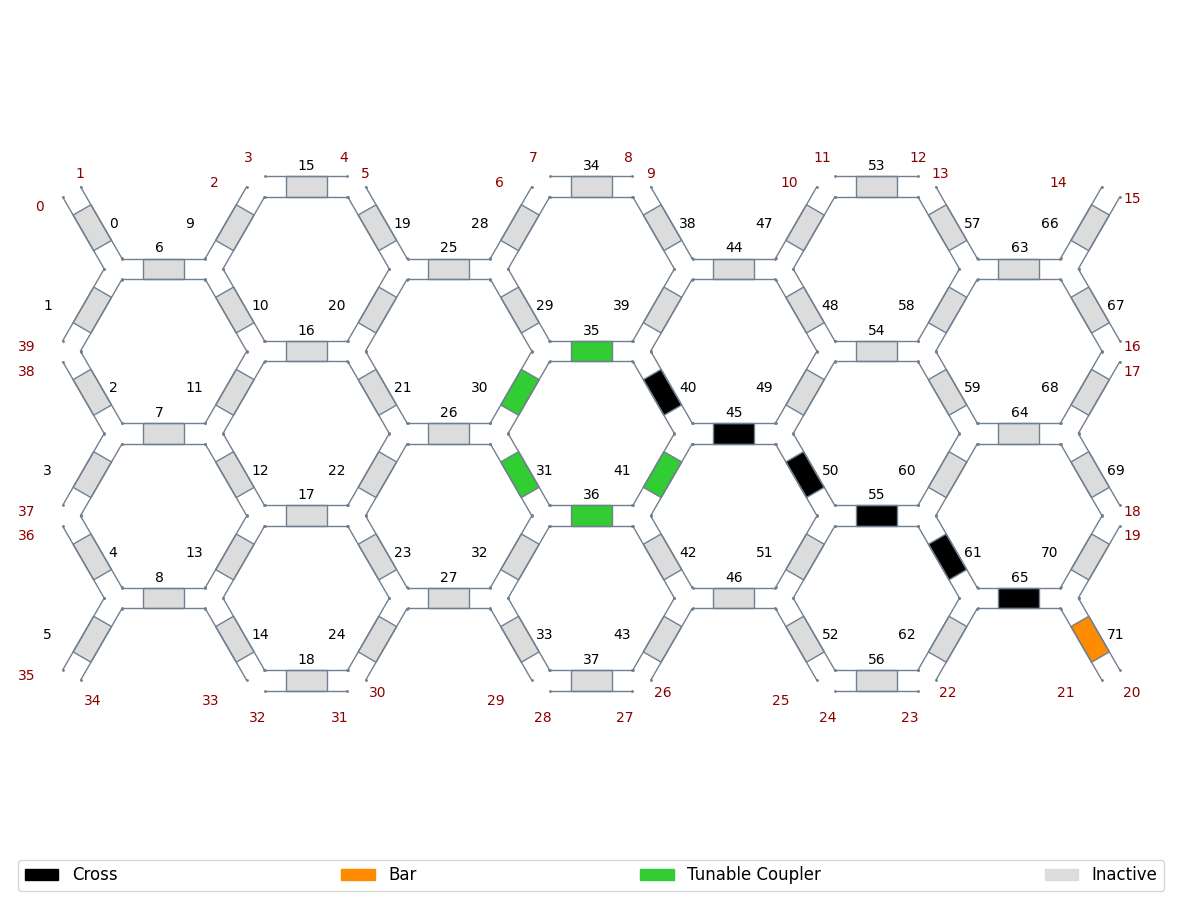

In [489]:
# ── CARGAR DATOS DEL PUERTO ACTIVO ────────────────────────────────────
import json, pathlib

RETOS_DIR = pathlib.Path('retos_v5')
with open(RETOS_DIR / f'challenges_ring_port{INPORT:02d}.json') as f:
    d_retos = json.load(f)

challenges        = [{int(k): v for k, v in ch.items()}
                     for ch in d_retos['challenges']]
route_pucs_inport = set(d_retos['route_pucs'])
dynamic_pucs      = d_retos['dynamic_pucs']
outports          = [p for p in ACTIVE_PORTS if p != INPORT]

print(f'Puerto:          {INPORT}')
print(f'TBUs de ruta:    {sorted(route_pucs_inport)}')
print(f'TBUs dinámicas:  {len(dynamic_pucs)}')
print(f'Retos cargados:  {len(challenges)}')

# Verificación solapamiento
solapamiento = route_pucs_inport & set(int(k) for k in challenges[0].keys())
assert not solapamiento, f'⚠ Solapamiento detectado: {solapamiento}'
print('✓ Sin solapamiento — OK para medir')
# Verificar visualmente la ruta del puerto activo
sl.reset_mesh()
sl.interconnect(puc_state_list=RUTAS[INPORT])
core_monitor.plot_mesh_status(display_ports=True)

In [490]:
sl.calibration()
print(sl.get_puc_coupling_factors(puc_ids=35))

[0.1743507413460148]


In [491]:
# ── CARGAR RETOS DEL PUERTO ACTIVO ────────────────────────────────────
import json, pathlib

RETOS_DIR = pathlib.Path('retos_v5')
with open(RETOS_DIR / f'challenges_ring_port{INPORT:02d}.json') as f:
    d_retos = json.load(f)

challenges        = [{int(k): v for k, v in ch.items()}
                     for ch in d_retos['challenges']]
route_pucs_inport = set(d_retos['route_pucs'])
dynamic_pucs      = d_retos['dynamic_pucs']

# Verificación solapamiento
solapamiento = route_pucs_inport & set(int(k) for k in challenges[0].keys())
assert not solapamiento, f'⚠ Solapamiento: {solapamiento}'
print(f'✓ Retos cargados para puerto {INPORT} — sin solapamiento')

✓ Retos cargados para puerto 21 — sin solapamiento


In [492]:
# ──NUEVA  MEDIDA ────────────────────────────────────────────────────────────
N_CHALLENGES_MEDIR = 500
sl.enable_internal_monitoring()
outports    = [p for p in ACTIVE_PORTS if p != INPORT]
powers_list = []
t0          = time.time()

barra    = widgets.IntProgress(value=0, min=0, max=N_CHALLENGES_MEDIR,
                               description='Midiendo:', bar_style='info',
                               layout=widgets.Layout(width='500px'))
etiqueta = widgets.Label(value=f'0 / {N_CHALLENGES_MEDIR}')
display(widgets.HBox([barra, etiqueta]))

sl.reset_mesh()
print(f'✓ Chip en estado limpio')
print(f'Puertos salida:  {len(outports)}')
print(f'Midiendo puerto: {INPORT}')

# ── FUNCIÓN DE RUTA CON CFs EXACTOS ──────────────────────────────────
def programar_ruta(inport, rutas, route_pucs):
    puc_conf = []
    for puc, estado in rutas[inport]:
        if estado == 'x':
            puc_conf.append((puc, [1.0, 0.0]))
        elif estado == '=':
            puc_conf.append((puc, [0.0, 0.0]))
        else:
            puc_conf.append((puc, [float(estado), 0.0]))
    sl.reset_puc(pucs_id=list(route_pucs))
    sl.set_coupling_factor_phase(puc_conf_info=puc_conf)
    
for idx, reto in enumerate(challenges[:N_CHALLENGES_MEDIR]):

    # 1. Programar ruta con CFs exactos
    programar_ruta(INPORT, RUTAS, route_pucs_inport)

    # 2. Aplicar fases aleatorias en TBUs dinámicas
    sl.set_driven_phases(reto, compensate_passive_phase=False)

    # 3. Leer potencias de salida
    powers = sl.get_output_power(inport=INPORT, outport=outports)
    powers_list.append({str(k): v for k, v in powers.items()})

    # Actualizar barra de progreso
    barra.value    = idx + 1
    elapsed        = time.time() - t0
    remaining      = (elapsed / (idx + 1)) * (N_CHALLENGES_MEDIR - idx - 1)
    etiqueta.value = (f'{idx+1} / {N_CHALLENGES_MEDIR}  |  '
                      f'{elapsed:.0f}s  |  ~{remaining:.0f}s restantes')

barra.bar_style = 'success'
t_total = time.time() - t0
print(f'\n✓ {len(powers_list)} retos medidos en {t_total:.1f}s  '
      f'({t_total/N_CHALLENGES_MEDIR:.2f}s por reto)')

# ── GUARDAR ───────────────────────────────────────────────────────────
fname = f'powers_anillo_{N_CHALLENGES_MEDIR}retos_port{INPORT:02d}.json'
with open(RESULTS_DIR / fname, 'w') as f:
    json.dump({
        'inport':    INPORT,
        'outports':  outports,
        'n_retos':   len(powers_list),
        'modo':      'anillo_isotropico',
        'elapsed_s': round(t_total, 2),
        'powers':    powers_list
    }, f, indent=2)
print(f'✓ Potencias guardadas en {RESULTS_DIR}/{fname}')

# ── PUERTOS PENDIENTES ────────────────────────────────────────────────
medidos    = sorted([int(p.stem.split(f'powers_anillo_{N_CHALLENGES_MEDIR}retos_port')[1].split('.')[0])
                     for p in RESULTS_DIR.glob(f'powers_anillo_{N_CHALLENGES_MEDIR}retos_port*.json')])
pendientes = [p for p in ACTIVE_PORTS if p not in medidos]
print(f'\nPuertos medidos:    {medidos}')
print(f'Puertos pendientes: {pendientes}')
if pendientes:
    print(f'\n→ Cambia INPORT = {pendientes[0]} en la Celda 1 '
          f'y ejecuta desde la Celda 6')

✓ Chip en estado limpio
Puertos salida:  27
Midiendo puerto: 21

✓ 500 retos medidos en 383.8s  (0.77s por reto)
✓ Potencias guardadas en resultados_v2/powers_anillo_500retos_port21.json


ValueError: invalid literal for int() with base 10: '19_v2'

In [116]:
N_CHALLENGES_MEDIR = 500
sl.enable_internal_monitoring()  
outports       = [p for p in ACTIVE_PORTS if p != INPORT]
powers_list = []
t0          = time.time()

barra    = widgets.IntProgress(value=0, min=0, max=N_CHALLENGES_MEDIR,
                               description='Midiendo:', bar_style='info',
                               layout=widgets.Layout(width='500px'))
etiqueta = widgets.Label(value=f'0 / {N_CHALLENGES_MEDIR}')
display(widgets.HBox([barra, etiqueta]))

sl.reset_mesh()
print('✓ Chip en estado limpio')

print(f'Puertos salida:  {len(outports)}')
print(f'Midiendo puerto {INPORT}')
for idx, reto in enumerate(challenges[:N_CHALLENGES_MEDIR]):

    # 1. Limpiar TBUs de ruta
    sl.reset_puc(pucs_id=list(route_pucs_inport))

    # 2. Programar gateway + anillo para este puerto
    sl.interconnect(puc_state_list=RUTAS[INPORT])

    # 3. Aplicar fases aleatorias en TBUs dinámicas
    sl.set_driven_phases(reto, compensate_passive_phase=False)

    # 4. Leer potencias de salida
    powers = sl.get_output_power(inport=INPORT, outport=outports)
    powers_list.append({str(k): v for k, v in powers.items()})

    # Actualizar barra de progreso
    barra.value    = idx + 1
    elapsed        = time.time() - t0
    remaining      = (elapsed / (idx + 1)) * (N_CHALLENGES_MEDIR - idx - 1)
    etiqueta.value = (f'{idx+1} / {N_CHALLENGES_MEDIR}  |  '
                      f'{elapsed:.0f}s  |  ~{remaining:.0f}s restantes')

barra.bar_style = 'success'
t_total = time.time() - t0
print(f'\n✓ {len(powers_list)} retos medidos en {t_total:.1f}s  '
      f'({t_total/N_CHALLENGES_MEDIR:.2f}s por reto)')

# Guardar potencias
fname = f'powers_anillo_{N_CHALLENGES_MEDIR}retos_port{INPORT:02d}.json'
with open(RESULTS_DIR / fname, 'w') as f:
    json.dump({
        'inport':    INPORT,
        'outports':  outports,
        'n_retos':   len(powers_list),
        'modo':      'anillo_isotropico',
        'elapsed_s': round(t_total, 2),
        'powers':    powers_list
    }, f, indent=2)
print(f'✓ Potencias guardadas en {RESULTS_DIR}/{fname}')

# Mostrar qué puertos faltan
medidos    = sorted([int(p.stem.split(f'powers_anillo_{N_CHALLENGES_MEDIR}retos_port')[1].split('.')[0])
                     for p in RESULTS_DIR.glob(f'powers_anillo_{N_CHALLENGES_MEDIR}retos_port*.json')])
pendientes = [p for p in ACTIVE_PORTS if p not in medidos]
print(f'\nPuertos medidos:    {medidos}')
print(f'Puertos pendientes: {pendientes}')
if pendientes:
    print(f'\n→ Cambia INPORT = {pendientes[0]} en la Celda 1 '
          f'y ejecuta desde la Celda 6')

✓ Chip en estado limpio
Puertos salida:  27
Midiendo puerto 0

✓ 500 retos medidos en 343.4s  (0.69s por reto)
✓ Potencias guardadas en resultados/powers_anillo_500retos_port00.json

Puertos medidos:    [0, 3]
Puertos pendientes: [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 34, 35, 36, 37, 38, 39]

→ Cambia INPORT = 1 en la Celda 1 y ejecuta desde la Celda 6


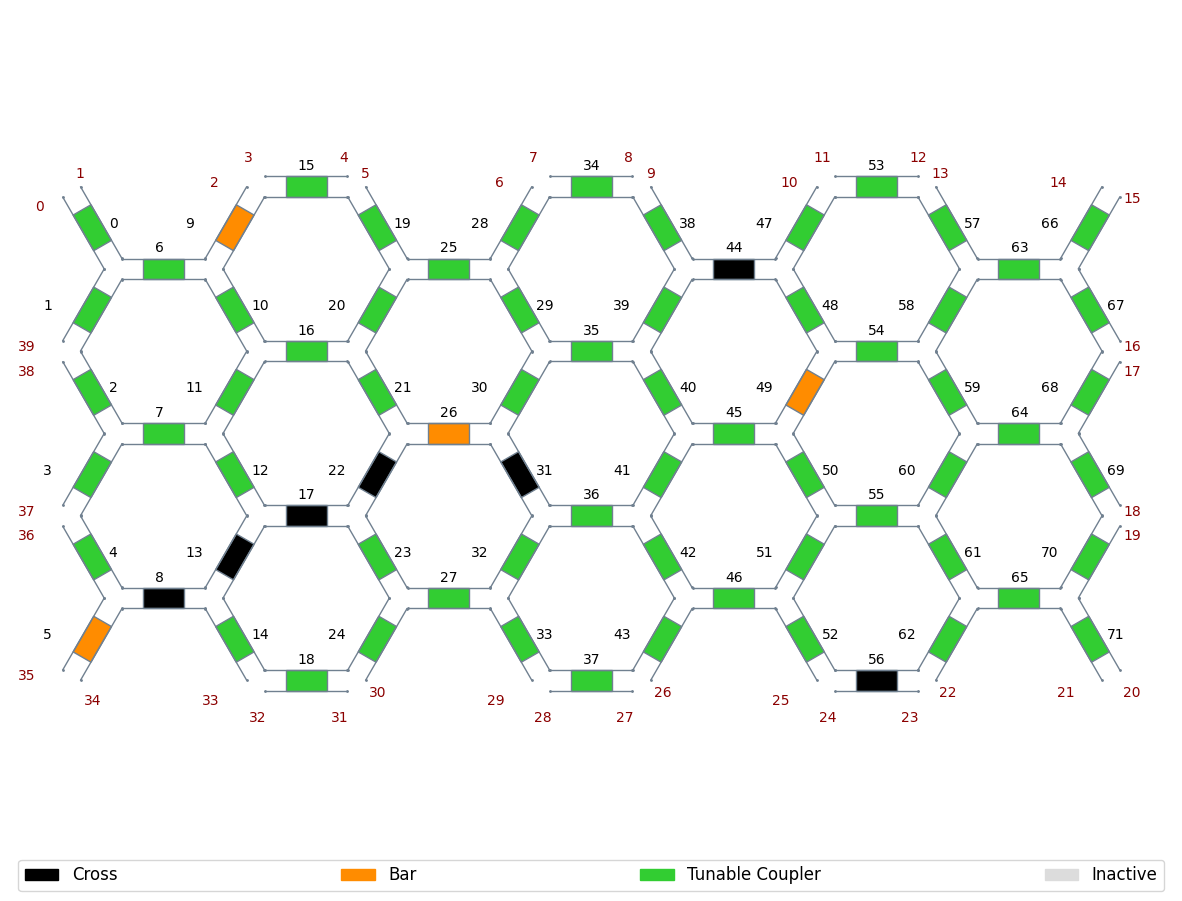

In [395]:
from smartlight.graphics import (
    MEMAMonitor,
    CoreMonitor,
    OpticalResponseVisualizer,
)
core_monitor = CoreMonitor(sl)
core_monitor.plot_mesh_status(display_ports=True)

In [397]:
cf = sl.get_puc_coupling_factors(puc_ids=[30])
print(f'Coupling factor PUC 0: {cf}')

Coupling factor PUC 0: [0.5000000000000001]


In [ ]:
import time
import numpy as np

INPORT_TEST = 38
RING_TUBUS  = [36, 41, 40, 35, 30]

# Gateway del puerto 38
GATEWAY_PORT38 = [(2,'x'),(7,'='),(11,'x'),(16,'='),(21,'x'),(26,'x'),(31,'x')]

outports_test = [p for p in ACTIVE_PORTS if p != INPORT_TEST]

sl.set_input_port(INPORT)
sl.enable_internal_monitoring()  

for cf_vals, label in [
    ([1/6, 1/5, 1/4, 1/3, 1/2],            'CF = 1/N'),
    ([1-1/6, 1-1/5, 1-1/4, 1-1/3, 1-1/2], 'CF = 1-1/N'),
]:
    ruta = GATEWAY_PORT38 + list(zip(RING_TUBUS, cf_vals))
    puc_conf = [(puc, [1.0 if e=='x' else 0.0 if e=='=' else float(e), 0.0])
                for puc, e in ruta]

    sl.reset_mesh()
    sl.set_coupling_factor_phase(puc_conf_info=puc_conf)
    time.sleep(0.3)

    powers = sl.get_output_power(inport=INPORT_TEST, outport=outports_test)
    vals   = np.array(list(powers.values()))
    vals_uw = 10**(vals/10) * 1e-3

    print(f'\n── {label} ─────────────────────────────')
    print(f'  Top 10 puertos de salida:')
    for p, v in sorted(powers.items(), key=lambda x: -x[1])[:10]:
        bar = '█' * int((v - vals.min()) / (vals.max() - vals.min()) * 20)
        print(f'    Puerto {p:>3}: {v:>7.2f} dBm  {bar}')
    print(f'  Std:            {vals.std():.3f} dBm')
    print(f'  Max - Min:      {vals.max()-vals.min():.3f} dBm')
    print(f'  Max/Min lineal: {vals_uw.max()/vals_uw.min():.1f}×')

sl.reset_mesh()
print('\n✓ Test completado — chip reseteado')


── CF = 1/N ─────────────────────────────
  Top 10 puertos de salida:
    Puerto   9:  -18.60 dBm  ████████████████████
    Puerto   6:  -21.81 dBm  █████████████████
    Puerto  14:  -24.03 dBm  ██████████████
    Puerto  39:  -24.44 dBm  ██████████████
    Puerto   7:  -25.22 dBm  █████████████
    Puerto  37:  -25.31 dBm  █████████████
    Puerto   3:  -25.68 dBm  █████████████
    Puerto  21:  -26.14 dBm  █████████████
    Puerto  12:  -26.34 dBm  ████████████
    Puerto  15:  -28.28 dBm  ███████████
  Std:            5.933 dBm
  Max - Min:      21.706 dBm
  Max/Min lineal: 148.1×

── CF = 1-1/N ─────────────────────────────
  Top 10 puertos de salida:
    Puerto  12:  -21.38 dBm  ████████████████████
    Puerto  14:  -21.38 dBm  ███████████████████
    Puerto  10:  -23.33 dBm  █████████████████
    Puerto   9:  -24.57 dBm  ████████████████
    Puerto  15:  -26.65 dBm  ██████████████
    Puerto  34:  -27.36 dBm  █████████████
    Puerto  21:  -27.64 dBm  ████████████
    Puerto  2

In [433]:
import time
import numpy as np

# Test definitivo — ¿por qué brazo salen los puertos de salida del anillo?
# Variamos CF de TBU 36 y vemos qué puerto de salida cambia más

INPORT_TEST   = 38
GATEWAY_PORT38 = [(2,'x'),(7,'='),(11,'x'),(16,'='),(21,'x'),(26,'x'),(31,'x')]
outports_test  = [p for p in ACTIVE_PORTS if p != INPORT_TEST]

print('Programando gateway del puerto 38...')
print('Variando CF de TBU 36 — viendo qué puertos cambian\n')
print(f'{"CF TBU36":>10}  ' + '  '.join(f'P{p:>3}' for p in outports_test))
print('-' * (12 + 6*len(outports_test)))

for cf in [0.0, 1/6, 1/5, 1/3, 0.5, 2/3, 1-1/6, 1.0]:
    # Gateway fijo + TBU 36 variable + resto del anillo fijo
    ruta = GATEWAY_PORT38 + [
        (36, 1/6),
        (41, 1/5), (40, 1/4), (35, cf), (30, 1/2)
    ]
    puc_conf = [(puc, [1.0 if e=='x' else 0.0 if e=='=' else float(e), 0.0])
                for puc, e in ruta]

    sl.reset_mesh()
    sl.set_coupling_factor_phase(puc_conf_info=puc_conf)
    time.sleep(0.3)

    powers = sl.get_output_power(inport=INPORT_TEST, outport=outports_test)
    vals   = [f'{powers.get(p, -60.0):>5.1f}' for p in outports_test]
    print(f'{cf:>10.4f}  ' + '  '.join(vals))

sl.reset_mesh()
print('\n✓ Chip reseteado')
print('\n→ El puerto cuya potencia AUMENTA al subir CF = brazo CROSS de TBU 36')
print('→ El puerto cuya potencia DISMINUYE al subir CF = brazo BAR de TBU 36')

Programando gateway del puerto 38...
Variando CF de TBU 36 — viendo qué puertos cambian

  CF TBU36  P  0  P  1  P  2  P  3  P  4  P  5  P  6  P  7  P  8  P  9  P 10  P 11  P 12  P 13  P 14  P 15  P 16  P 17  P 18  P 19  P 20  P 21  P 34  P 35  P 36  P 37  P 39
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0.0000  -28.5  -32.1  -33.0  -38.2  -38.8  -31.7  -33.8  -26.2  -37.3  -19.0  -25.2  -38.0  -26.5  -34.5  -24.9  -29.0  -33.6  -31.8  -32.7  -37.0  -29.1  -25.3  -31.6  -35.3  -37.4  -26.3  -32.4
    0.1667  -29.5  -31.9  -34.3  -30.0  -38.9  -29.5  -24.4  -26.3  -36.4  -19.0  -27.3  -38.0  -25.8  -35.7  -24.2  -28.5  -34.2  -31.5  -32.9  -36.4  -29.4  -25.4  -35.8  -36.7  -37.6  -25.9  -27.4
    0.2000  -29.2  -32.3  -34.5  -29.5  -38.4  -29.0  -23.7  -26.3  -35.9  -18.9  -27.5  -38.0  -25.8  -35.8  -24.2  -28.4  -34.2  -31.5  -33.1  -37.0  -29.4  -25.

In [106]:
import json
import pathlib

# ── CARGAR RETOS DEL PUERTO ACTIVO ────────────────────────────────────
RETOS_DIR = pathlib.Path('retos')
fname_retos = RETOS_DIR / f'challenges_ring_port{INPORT:02d}.json'

with open(fname_retos) as f:
    d_retos = json.load(f)

challenges       = [{int(k): v for k, v in ch.items()}
                    for ch in d_retos['challenges']]
dynamic_pucs     = d_retos['dynamic_pucs']
route_pucs_inport = set(d_retos['route_pucs'])

print(f'Retos cargados:      {len(challenges)}')
print(f'TBUs dinámicas:      {len(dynamic_pucs)}')
print(f'TBUs de ruta:        {len(route_pucs_inport)}')
print(f'Seed usado:          {d_retos["seed"]}')

# ── MEDIR ─────────────────────────────────────────────────────────────
N_CHALLENGES_MEDIR = 500
powers_list = []
t0          = time.time()

barra    = widgets.IntProgress(value=0, min=0, max=N_CHALLENGES_MEDIR,
                               description='Midiendo:', bar_style='info',
                               layout=widgets.Layout(width='500px'))
etiqueta = widgets.Label(value=f'0 / {N_CHALLENGES_MEDIR}')
display(widgets.HBox([barra, etiqueta]))

sl.reset_mesh()
print('✓ Chip en estado limpio')

for idx, reto in enumerate(challenges[:N_CHALLENGES_MEDIR]):

    # 1. Limpiar TBUs de ruta
    sl.reset_puc(pucs_id=list(route_pucs_inport))

    # 2. Programar gateway + anillo para este puerto
    sl.interconnect(puc_state_list=RUTAS[INPORT])

    # 3. Aplicar fases aleatorias en TBUs dinámicas
    sl.set_driven_phases(reto, compensate_passive_phase=False)

    # 4. Leer potencias de salida
    powers = sl.get_output_power(inport=INPORT, outport=outports)
    powers_list.append({str(k): v for k, v in powers.items()})

    barra.value    = idx + 1
    elapsed        = time.time() - t0
    remaining      = (elapsed / (idx + 1)) * (N_CHALLENGES_MEDIR - idx - 1)
    etiqueta.value = (f'{idx+1} / {N_CHALLENGES_MEDIR}  |  '
                      f'{elapsed:.0f}s  |  ~{remaining:.0f}s restantes')

barra.bar_style = 'success'
t_total = time.time() - t0
print(f'\n✓ {len(powers_list)} retos medidos en {t_total:.1f}s  '
      f'({t_total/N_CHALLENGES_MEDIR:.2f}s por reto)')

# Guardar potencias
fname = f'powers_anillo_{N_CHALLENGES_MEDIR}retos_port{INPORT:02d}.json'
with open(RESULTS_DIR / fname, 'w') as f:
    json.dump({
        'inport':    INPORT,
        'outports':  outports,
        'n_retos':   len(powers_list),
        'modo':      'anillo_isotropico',
        'elapsed_s': round(t_total, 2),
        'powers':    powers_list
    }, f, indent=2)
print(f'✓ Potencias guardadas en {RESULTS_DIR}/{fname}')

medidos    = sorted([int(p.stem.split(f'powers_anillo_{N_CHALLENGES_MEDIR}retos_port')[1].split('.')[0])
                     for p in RESULTS_DIR.glob(f'powers_anillo_{N_CHALLENGES_MEDIR}retos_port*.json')])
pendientes = [p for p in ACTIVE_PORTS if p not in medidos]
print(f'\nPuertos medidos:    {medidos}')
print(f'Puertos pendientes: {pendientes}')
if pendientes:
    print(f'\n→ Cambia INPORT = {pendientes[0]} en la Celda 1 '
          f'y ejecuta desde la Celda 6')

Retos cargados:      1000
TBUs dinámicas:      61
TBUs de ruta:        11
Seed usado:          45


✓ Chip en estado limpio

✓ 500 retos medidos en 342.8s  (0.69s por reto)
✓ Potencias guardadas en resultados/powers_anillo_500retos_port03.json

Puertos medidos:    [3]
Puertos pendientes: [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 34, 35, 36, 37, 38, 39]

→ Cambia INPORT = 0 en la Celda 1 y ejecuta desde la Celda 6


In [86]:
# Ver cuántos puertos tiene powers
print(f'Puertos en outports: {len(outports)}')
print(f'Puertos en powers:   {len(powers)}')
print(f'Puertos detectados:  {sorted(powers.keys())}')

Puertos en outports: 27
Puertos en powers:   27
Puertos detectados:  [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 34, 35, 36, 37, 38, 39]


In [87]:
# Ver longitud firma con todos los outports vs los detectados
sig_todos     = lehmer_gray_signature(powers, outports)
sig_detectados = lehmer_gray_signature(powers, list(powers.keys()))

print(f'Firma con outports:    {len(sig_todos)} bits')
print(f'Firma con detectados:  {len(sig_detectados)} bits')

Firma con outports:    109 bits
Firma con detectados:  109 bits


In [99]:
import json, time, random, pathlib
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# ── PARÁMETROS ────────────────────────────────────────────────────────
N_CHALLENGES_RANDOM = 500
SEED_RANDOM         = 99   # seed diferente al experimento principal
FASE_MAX            = 2 * np.pi
RESULTS_DIR         = pathlib.Path('resultados')

# ── GENERAR RETOS ALEATORIOS ──────────────────────────────────────────
# En modo aleatorio NO hay rutas maestras — se aplican fases aleatorias
# a TODAS las PUCs del chip (no solo las dinámicas)
ALL_PUCS = list(range(72))

rng_random     = random.Random(SEED_RANDOM)
challenges_random = [
    {puc: [round(rng_random.uniform(0.0, FASE_MAX), 4), 0.0]
     for puc in ALL_PUCS}
    for _ in range(N_CHALLENGES_RANDOM)
]

print(f'Retos aleatorios generados: {len(challenges_random)}')
print(f'PUCs por reto:              {len(challenges_random[0])}')
print(f'Rango fases:                [0, 2π] rad')

with open(RESULTS_DIR / 'challenges_random.json', 'w') as f:
    json.dump([{str(k): v for k, v in ch.items()}
               for ch in challenges_random], f, indent=2)
print(f'✓ Guardado en {RESULTS_DIR}/challenges_random.json')

# ── MEDIR ─────────────────────────────────────────────────────────────
ACTIVE_PORTS = list(range(0, 22)) + list(range(34, 40))
INPORT       = 3
outports     = [p for p in ACTIVE_PORTS if p != INPORT]

powers_random = []
t0            = time.time()

barra    = widgets.IntProgress(value=0, min=0, max=N_CHALLENGES_RANDOM,
                               description='Midiendo:', bar_style='info',
                               layout=widgets.Layout(width='500px'))
etiqueta = widgets.Label(value=f'0 / {N_CHALLENGES_RANDOM}')
display(widgets.HBox([barra, etiqueta]))

for idx, reto in enumerate(challenges_random):

    # Reset completo del chip — sin ruta maestra
    sl.reset_mesh()

    # Aplicar fases aleatorias a todas las PUCs
    sl.set_driven_phases(reto, compensate_passive_phase=False)

    # Leer potencias
    powers = sl.get_output_power(inport=INPORT, outport=outports)
    powers_random.append({str(k): v for k, v in powers.items()})

    barra.value    = idx + 1
    elapsed        = time.time() - t0
    remaining      = (elapsed / (idx + 1)) * (N_CHALLENGES_RANDOM - idx - 1)
    etiqueta.value = (f'{idx+1}/{N_CHALLENGES_RANDOM}  |  '
                      f'{elapsed:.0f}s  |  ~{remaining:.0f}s restantes')

barra.bar_style = 'success'
t_total = time.time() - t0
print(f'\n✓ {len(powers_random)} retos medidos en {t_total:.1f}s  '
      f'({t_total/N_CHALLENGES_RANDOM:.2f}s por reto)')

# Guardar potencias
fname_out = RESULTS_DIR / f'powers_random_{N_CHALLENGES_RANDOM}retos_port{INPORT:02d}.json'
with open(fname_out, 'w') as f:
    json.dump({
        'inport':      INPORT,
        'outports':    outports,
        'n_retos':     len(powers_random),
        'modo':        'aleatorio_completo',
        'elapsed_s':   round(t_total, 2),
        'powers':      powers_random
    }, f, indent=2)
print(f'✓ Potencias guardadas en {fname_out}')

Retos aleatorios generados: 500
PUCs por reto:              72
Rango fases:                [0, 2π] rad
✓ Guardado en resultados/challenges_random.json



✓ 500 retos medidos en 388.8s  (0.78s por reto)
✓ Potencias guardadas en resultados/powers_random_500retos_port03.json


In [98]:
import time
import json
import pathlib
import ipywidgets as widgets
from IPython.display import display

# ── PARÁMETROS ────────────────────────────────────────────────────────
N_REP      = 100      # repeticiones del mismo reto
RETO_IDX   = 0        # índice del reto a usar
WAIT_S     = 0.5      # espera entre medidas para estabilización térmica
RESULTS_DIR = pathlib.Path('resultados')

# ── RETO DE REFERENCIA ────────────────────────────────────────────────
reto_ref = challenges[RETO_IDX]
print(f'Puerto entrada:     {INPORT}')
print(f'Reto de referencia: índice {RETO_IDX}')
print(f'Repeticiones:       {N_REP}')
print(f'Espera entre meds:  {WAIT_S}s')

# ── MEDIR ─────────────────────────────────────────────────────────────
powers_estabilidad = []
t0 = time.time()

barra    = widgets.IntProgress(value=0, min=0, max=N_REP,
                               description='Midiendo:', bar_style='info',
                               layout=widgets.Layout(width='500px'))
etiqueta = widgets.Label(value=f'0 / {N_REP}')
display(widgets.HBox([barra, etiqueta]))

for rep in range(N_REP):
    sl.reset_puc(pucs_id=list(route_pucs_inport))
    sl.interconnect(puc_state_list=RUTAS[INPORT])
    sl.set_driven_phases(reto_ref, compensate_passive_phase=True)
    time.sleep(WAIT_S)

    powers = sl.get_output_power(inport=INPORT, outport=outports)
    powers_estabilidad.append({str(k): v for k, v in powers.items()})

    barra.value    = rep + 1
    elapsed        = time.time() - t0
    remaining      = (elapsed / (rep + 1)) * (N_REP - rep - 1)
    etiqueta.value = (f'{rep+1}/{N_REP}  |  '
                      f'{elapsed:.0f}s  |  ~{remaining:.0f}s restantes')

barra.bar_style = 'success'
t_total = time.time() - t0
print(f'\n✓ {N_REP} repeticiones medidas en {t_total:.1f}s  '
      f'({t_total/N_REP:.2f}s por repetición)')

# ── GUARDAR ───────────────────────────────────────────────────────────
fname_out = RESULTS_DIR / f'estabilidad_port{INPORT:02d}_reto{RETO_IDX}_wait{WAIT_S}.json'
with open(fname_out, 'w') as f:
    json.dump({
        'inport':    INPORT,
        'outports':  outports,
        'reto_idx':  RETO_IDX,
        'n_rep':     N_REP,
        'wait_s':    WAIT_S,
        'elapsed_s': round(t_total, 2),
        'powers':    powers_estabilidad
    }, f, indent=2)
print(f'✓ Guardado en {fname_out}')

Puerto entrada:     3
Reto de referencia: índice 0
Repeticiones:       100
Espera entre meds:  0.5s



✓ 100 repeticiones medidas en 120.7s  (1.21s por repetición)
✓ Guardado en resultados/estabilidad_port03_reto0_wait0.5.json


Midiendo barrido de fase — PUC 15, puerto salida 4...
   360.0°  →  -3.1377 dBmm
✓ Medida completada — 65 puntos


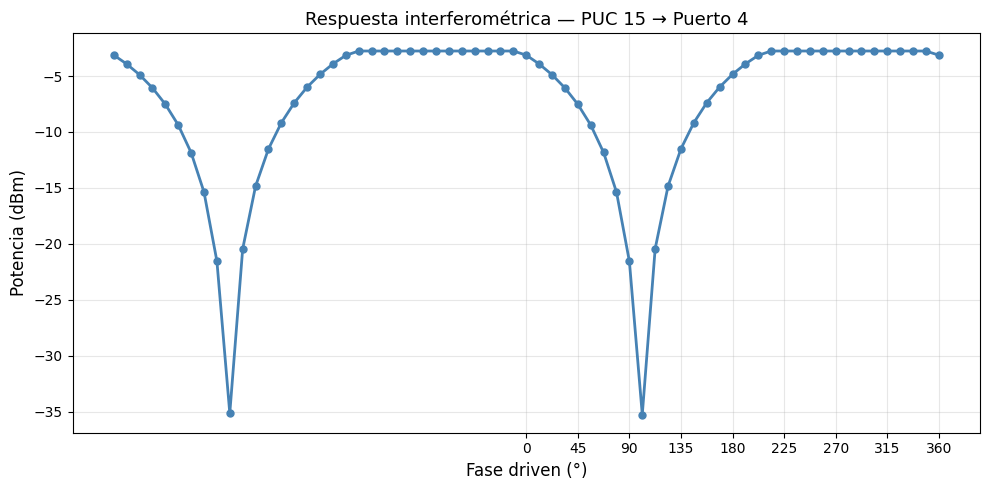

✓ Figura guardada


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

# ── PARÁMETROS ────────────────────────────────────────────────────────
PUC_TEST     = 15
OUTPORT_TEST = 4
FASE_MIN     = -(2 * np.pi)
FASE_MAX     = 2 * np.pi
FASE_STEP    = np.pi / 16   # más resolución
WAIT_S       = 0.5

fases     = np.arange(FASE_MIN, FASE_MAX + FASE_STEP/2, FASE_STEP)
potencias = []

print(f'Midiendo barrido de fase — PUC {PUC_TEST}, puerto salida {OUTPORT_TEST}...')

for fase in fases:
    sl.set_driven_phases({PUC_TEST: [fase, 0.0]},compensate_passive_phase=True)
    time.sleep(WAIT_S)
    powers = sl.get_output_power(inport=INPORT, outport=[OUTPORT_TEST])
    potencias.append(powers[OUTPORT_TEST])
    print(f'  {np.degrees(fase):>6.1f}°  →  {powers[OUTPORT_TEST]:.4f} dBm', end='\r')

# Resetear
sl.set_driven_phases({PUC_TEST: [0.0, 0.0]})
print(f'\n✓ Medida completada — {len(fases)} puntos')

# ── PLOT ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.degrees(fases), potencias, 'o-',
        color='steelblue', linewidth=2, markersize=5)
ax.set_xlabel('Fase driven (°)', fontsize=12)
ax.set_ylabel('Potencia (dBm)', fontsize=12)
ax.set_title(f'Respuesta interferométrica — PUC {PUC_TEST} → Puerto {OUTPORT_TEST}',
             fontsize=13)
ax.set_xticks([0, 45, 90, 135, 180, 225, 270, 315, 360])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'barrido_fase_PUC{PUC_TEST}_port{OUTPORT_TEST}.png', dpi=150)
plt.show()
print('✓ Figura guardada')

Midiendo barrido de fase — PUC 15, puerto salida 4...
   360.0°  →  -35.8135 dBm
✓ Medida completada — 65 puntos


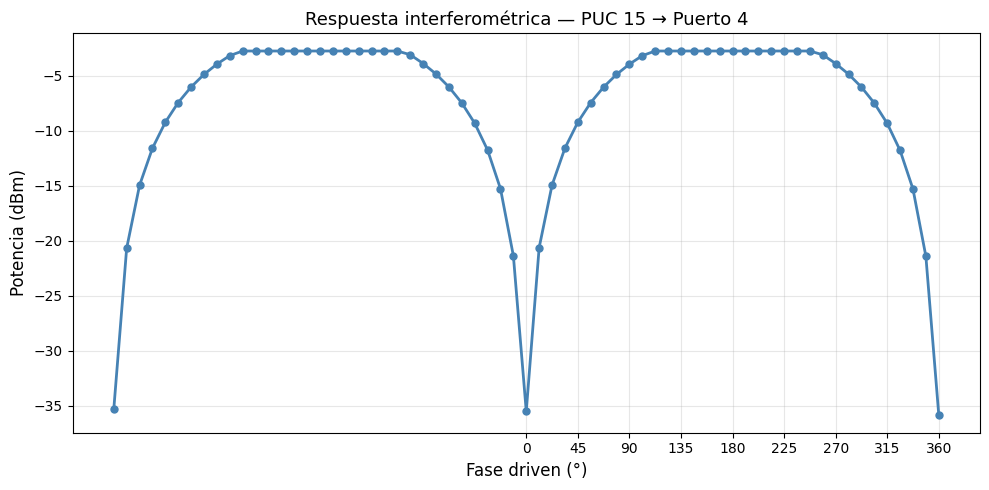

✓ Figura guardada


In [83]:
import time
import numpy as np
import matplotlib.pyplot as plt

# ── PARÁMETROS ────────────────────────────────────────────────────────
PUC_TEST     = 15
OUTPORT_TEST = 4
FASE_MIN     = -(2 * np.pi)
FASE_MAX     = 2 * np.pi
FASE_STEP    = np.pi / 16   # más resolución
WAIT_S       = 0.5

fases     = np.arange(FASE_MIN, FASE_MAX + FASE_STEP/2, FASE_STEP)
potencias = []

print(f'Midiendo barrido de fase — PUC {PUC_TEST}, puerto salida {OUTPORT_TEST}...')

for fase in fases:
    sl.set_driven_phases({PUC_TEST: [fase, 0.0]},compensate_passive_phase=True)
    time.sleep(WAIT_S)
    powers = sl.get_output_power(inport=INPORT, outport=[OUTPORT_TEST])
    potencias.append(powers[OUTPORT_TEST])
    print(f'  {np.degrees(fase):>6.1f}°  →  {powers[OUTPORT_TEST]:.4f} dBm', end='\r')

# Resetear
sl.set_driven_phases({PUC_TEST: [0.0, 0.0]})
print(f'\n✓ Medida completada — {len(fases)} puntos')

# ── PLOT ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.degrees(fases), potencias, 'o-',
        color='steelblue', linewidth=2, markersize=5)
ax.set_xlabel('Fase driven (°)', fontsize=12)
ax.set_ylabel('Potencia (dBm)', fontsize=12)
ax.set_title(f'Respuesta interferométrica — PUC {PUC_TEST} → Puerto {OUTPORT_TEST}',
             fontsize=13)
ax.set_xticks([0, 45, 90, 135, 180, 225, 270, 315, 360])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'barrido_fase_PUC{PUC_TEST}_port{OUTPORT_TEST}.png', dpi=150)
plt.show()
print('✓ Figura guardada')

In [65]:
import time
import numpy as np

# ── PARÁMETROS ────────────────────────────────────────────────────────
PUC_TEST     = 15
OUTPORT_TEST = 4       # ← puerto de salida a monitorizar
I_MIN_A      = 0.000
I_MAX_A      = 0.010
I_STEP_A     = 0.001
WAIT_S       = 1

sl.reset_mesh()
# ── CANAL MEDA ───────────────────────────────────────────────────────
canal_up = meda.get_mapping_list(PUC_TEST)[0]
print(f'Puerto entrada:  {INPORT}')
print(f'Puerto salida:   {OUTPORT_TEST}')
print(f'PUC test:        {PUC_TEST}  →  canal MEDA {canal_up}')
print(f'Rango:           [{I_MIN_A*1000:.1f}, {I_MAX_A*1000:.1f}] mA  '
      f'paso={I_STEP_A*1000:.1f} mA')
print()
print(f'{"Corriente (mA)":>15}  {"Potencia (dBm)":>15}')
print('-' * 33)

corrientes = np.arange(I_MIN_A, I_MAX_A + I_STEP_A/2, I_STEP_A)

for corriente in corrientes:
    meda.set_channel_current(core=wma, channel=canal_up,
                             value=corriente, updatephase=True)
    time.sleep(WAIT_S)
    powers = sl.get_output_power(inport=INPORT, outport=[OUTPORT_TEST])
    potencia = powers[OUTPORT_TEST]
    print(f'{corriente*1000:>15.2f}  {potencia:>15.4f}')

meda.set_channel_current(core=wma, channel=canal_up, value=0.0, updatephase=False)
print('\n✓ Canal reseteado a 0')

Puerto entrada:  3
Puerto salida:   4
PUC test:        15  →  canal MEDA 174
Rango:           [0.0, 10.0] mA  paso=1.0 mA

 Corriente (mA)   Potencia (dBm)
---------------------------------
           0.00          -3.1447
           1.00          -3.1486
           2.00          -3.1474
           3.00          -3.1446
           4.00          -3.1457
           5.00          -3.1393
           6.00          -3.1397
           7.00          -3.1421
           8.00          -3.1424
           9.00          -3.1398
          10.00          -3.1419

✓ Canal reseteado a 0


In [30]:
channels = meda.get_allchannels_current()

In [ ]:
import time

print(f'Puerto entrada: {INPORT}')
print(f'Canal MEDA: 161 (PUC 1, heater up)')
print()
print(f'{"Corriente (mA)":>15}  {"Max potencia (dBm)":>20}')
print('-' * 38)

for corriente in [0.001, 0.002, 0.003, 1.5, 2.0, 1.0, 0.0]:
    meda.set_channel_current(core=wma, channel=161,
                             value=corriente, updatephase=False)
    time.sleep(0.2)  # esperar estabilización térmica
    powers = sl.get_output_power(inport=INPORT, outport=outports)
    max_p  = max(powers.values())
    print(f'{corriente:>15.3f}  {max_p:>20.4f}')

# Resetear a 0
meda.set_channel_current(core=wma, channel=161, value=0.0, updatephase=False)
print('\n✓ Canal reseteado a 0')

In [21]:
meda.connect()

In [23]:
meda.set_channel_current(core = sl, channel = 161, value= 2.0,updatephase=False)

AttributeError: 'MEMAPromwad' object has no attribute 'set_channel_current'

In [16]:
channel = meda.get_allchannels_current()


In [17]:
print(channel)

None


In [18]:
# Generar mapping virtual sin offset
meda.generate_general_mapping()
print('✓ generate_general_mapping')

# Ver el nuevo mapping
nuevo_map = meda.get_mapping()
print('Nuevos canales PUC 0:', meda.get_mapping_list(0))
print('Nuevos canales PUC 1:', meda.get_mapping_list(1))

# Probar setear corriente con el nuevo mapping
puc_test = dynamic_pucs[0]
try:
    meda.set_multichannel_current(core=wma, currents_dict={puc_test: 2.0})
    print(f'✓ PUC {puc_test} a 2.0 mA')
    meda.set_multichannel_current(core=wma, currents_dict={puc_test: 0.0})
    print('✓ Reseteado')
except Exception as e:
    print(f'✗ {e}')

AttributeError: 'MEDAStacked' object has no attribute 'generate_general_mapping'

In [ ]:
signatures  = []
powers_list = []
t0          = time.time()

# Barra de progreso con ipywidgets
barra    = widgets.IntProgress(value=0, min=0, max=N_CHALLENGES,
                               description='Midiendo:', bar_style='info',
                               layout=widgets.Layout(width='500px'))
etiqueta = widgets.Label(value=f'0 / {N_CHALLENGES}')
display(widgets.HBox([barra, etiqueta]))

for idx, reto in enumerate(challenges):

    # 1. Limpiar TBUs de ruta
    sl.reset_puc(pucs_id=ALL_ROUTE_PUCS)

    # 2. Programar gateway + anillo para este puerto
    sl.interconnect(puc_state_list=RUTAS[INPORT])

    # 3. Corrientes crudas en TBUs dinámicas  →  φ_total = φ₀ + Δφ(I)
    meda.set_multichannel_current(core=wma, currents_dict=reto)

    # 4. Leer potencias de salida
    powers = sl.get_output_power(inport=INPORT, outport=outports)

    # 5. Binarizar con Lehmer-Gray
    sig = lehmer_gray_signature(powers, outports)

    signatures.append(sig)
    powers_list.append({str(k): v for k, v in powers.items()})

    # Actualizar barra de progreso
    barra.value    = idx + 1
    elapsed        = time.time() - t0
    remaining      = (elapsed / (idx + 1)) * (N_CHALLENGES - idx - 1)
    etiqueta.value = (f'{idx+1} / {N_CHALLENGES}  |  '
                      f'{elapsed:.0f}s  |  ~{remaining:.0f}s restantes')

barra.bar_style = 'success'
t_total = time.time() - t0
print(f'\n✓ {len(signatures)} retos medidos en {t_total:.1f}s  '
      f'({t_total/N_CHALLENGES:.2f}s por reto)')
print(f'  Longitud de cada firma: {len(signatures[0])} bits')

# Guardar resultados del puerto
fname = f'port_{INPORT:02d}.json'
with open(RESULTS_DIR / fname, 'w') as f:
    json.dump({'inport': INPORT, 'outports': outports,
               'sig_length': len(signatures[0]), 'elapsed_s': round(t_total, 2),
               'signatures': signatures, 'powers': powers_list}, f, indent=2)
print(f'  Guardado en {RESULTS_DIR}/{fname}')

# Mostrar qué puertos faltan
medidos    = sorted([int(p.stem.split('_')[1]) for p in RESULTS_DIR.glob('port_*.json')])
pendientes = [p for p in ACTIVE_PORTS if p not in medidos]
print(f'\nPuertos medidos:    {medidos}')
print(f'Puertos pendientes: {pendientes}')
if pendientes:
    print(f'\n→ Cambia INPORT = {pendientes[0]} en la Celda 1 y ejecuta desde la Celda 6')

MEDAGeneralException: Request 'SET CURRENTS' got no response and was canceled due to timeout

## Celda 8 — Comprobar reproducibilidad
Repite el mismo reto 10 veces y mide la HD entre las firmas.
Debe ser ≈ 0. Si es > 0.05 el chip no está estable.

In [ ]:
N_REP = 10
sigs_rep = []

print(f'Repitiendo reto 0 — {N_REP} veces...')
for rep in range(N_REP):
    sl.reset_puc(pucs_id=ALL_ROUTE_PUCS)
    sl.interconnect(puc_state_list=RUTAS[INPORT])
    meda.set_multichannel_current(core=wma, currents_dict=challenges[0])
    p = sl.get_output_power(inport=INPORT, outport=outports)
    sigs_rep.append(lehmer_gray_signature(p, outports))
    print(f'  Rep {rep+1:2d}/{N_REP}', end='\r')

ref     = sigs_rep[0]
hd_vals = [hamming_distance(ref, s) for s in sigs_rep[1:]]
hd_r    = sum(hd_vals) / len(hd_vals)

print(f'\n{"Rep":>5}  {"HD vs rep 1":>12}')
print('-' * 20)
for i, hd in enumerate(hd_vals, start=2):
    print(f'{i:>5}  {hd:>12.4f}')

print(f'\nHD_r medio: {hd_r:.4f}  (umbral: < 0.05)')
if hd_r < 0.05:
    print('✓ Chip estable')
else:
    print('⚠ Inestabilidad detectada — espera a que se estabilice la temperatura')

## Celda 9 — Calcular métricas PUF
Ejecutar cuando hayas medido todos los puertos que quieras.
Lee todos los ficheros `port_XX.json` y calcula las métricas pre y post SHA-256.

In [ ]:
port_files = sorted(RESULTS_DIR.glob('port_*.json'))
print(f'Puertos encontrados: {[f.stem for f in port_files]}')
print()

todas_sigs = []
for pf in port_files:
    with open(pf) as f:
        d = json.load(f)
    todas_sigs.extend(d['signatures'])
    print(f'  {pf.stem}: {len(d["signatures"])} firmas  |  {d["sig_length"]} bits')

print(f'\nFirmas totales: {len(todas_sigs)}')

# Independencia
hd_pairs = [hamming_distance(todas_sigs[i], todas_sigs[j])
             for i in range(len(todas_sigs))
             for j in range(i+1, min(i+21, len(todas_sigs)))]
independencia = sum(hd_pairs) / len(hd_pairs)

# Uniformidad
uniformidad = sum(sum(s)/len(s) for s in todas_sigs) / len(todas_sigs)

# Bit aliasing
min_len = min(len(s) for s in todas_sigs)
mat     = np.array([s[:min_len] for s in todas_sigs], dtype=float)
ba      = float(np.mean(np.abs(mat.mean(axis=0) - 0.5)))

# Post-SHA256
sigs_hash      = [sha256_bits(s) for s in todas_sigs]
unif_hash      = sum(sum(s)/len(s) for s in sigs_hash) / len(sigs_hash)
mat_h          = np.array(sigs_hash, dtype=float)
ba_hash        = float(np.mean(np.abs(mat_h.mean(axis=0) - 0.5)))
hd_hash_pairs  = [hamming_distance(sigs_hash[i], sigs_hash[j])
                  for i in range(len(sigs_hash))
                  for j in range(i+1, min(i+21, len(sigs_hash)))]
indep_hash     = sum(hd_hash_pairs) / len(hd_hash_pairs)

print()
print(f'{"Métrica":<30} {"Medido":>10} {"GT simulado":>12}')
print('=' * 55)
print(f'{"[Pre-hash]":<30}')
print(f'{"  Independencia HD":<30} {independencia:>10.4f} {0.4418:>12.4f}')
print(f'{"  Uniformidad":<30} {uniformidad:>10.4f} {0.4671:>12.4f}')
print(f'{"  Bit aliasing":<30} {ba:>10.4f} {0.1257:>12.4f}')
print(f'{"  Longitud firma (bits)":<30} {min_len:>10}  {3052:>11}')
print(f'{"[Post-SHA256]":<30}')
print(f'{"  Independencia HD":<30} {indep_hash:>10.4f} {0.5005:>12.4f}')
print(f'{"  Uniformidad":<30} {unif_hash:>10.4f} {0.5000:>12.4f}')
print(f'{"  Bit aliasing":<30} {ba_hash:>10.4f} {0.0000:>12.4f}')

metricas = {
    'puertos': [f.stem for f in port_files], 'firmas': len(todas_sigs),
    'longitud_bits': min_len, 'independencia': independencia,
    'uniformidad': uniformidad, 'bit_aliasing': ba,
    'independencia_hash': indep_hash, 'uniformidad_hash': unif_hash,
    'bit_aliasing_hash': ba_hash,
}
with open(RESULTS_DIR / 'metricas.json', 'w') as f:
    json.dump(metricas, f, indent=2)
print(f'\nGuardado en {RESULTS_DIR}/metricas.json')

## Celda 10 — Desconectar el chip
Ejecutar **siempre al terminar**, aunque haya habido errores.

In [496]:
import time
import numpy as np

# ── PARÁMETROS ────────────────────────────────────────────────────────
INPORT_TEST   = 21
RUTA_TEST     = RUTAS[21]   # ← sustituye si tienes una ruta específica
OUTPORTS_TEST = [10, 11]
N_MEDIDAS     = 20
WAIT          = 0.3         # segundos entre medidas

# ── PROGRAMAR RUTA ────────────────────────────────────────────────────
puc_conf = [
    (puc, [1.0 if e == 'x' else 0.0 if e == '=' else float(e), 0.0])
    for puc, e in RUTA_TEST
]
sl.reset_mesh()
sl.set_coupling_factor_phase(puc_conf_info=puc_conf)
time.sleep(0.5)
print(f'✓ Ruta programada — puerto entrada {INPORT_TEST}')
print(f'  Midiendo {N_MEDIDAS} veces con {WAIT}s entre medidas...\n')

# ── MEDIR ─────────────────────────────────────────────────────────────
print(f'{"#":>4}  {"Puerto 10 (dBm)":>16}  {"Puerto 11 (dBm)":>16}  {"Ratio 10/11":>12}')
print('-' * 55)

dbm_10_list = []
dbm_11_list = []

for i in range(N_MEDIDAS):
    powers = sl.get_output_power(inport=INPORT_TEST, outport=OUTPORTS_TEST)
    dbm_10 = powers.get(10, -60.0)
    dbm_11 = powers.get(11, -60.0)
    uw_10  = 10 ** (dbm_10 / 10) * 1e3
    uw_11  = 10 ** (dbm_11 / 10) * 1e3
    ratio  = uw_10 / (uw_11 + 1e-12)
    dbm_10_list.append(dbm_10)
    dbm_11_list.append(dbm_11)
    print(f'{i+1:>4}  {dbm_10:>16.4f}  {dbm_11:>16.4f}  {ratio:>12.4f}')
    time.sleep(WAIT)

# ── ESTADÍSTICAS ──────────────────────────────────────────────────────
dbm_10_arr = np.array(dbm_10_list)
dbm_11_arr = np.array(dbm_11_list)
uw_10_arr  = 10 ** (dbm_10_arr / 10) * 1e3
uw_11_arr  = 10 ** (dbm_11_arr / 10) * 1e3
ratios     = uw_10_arr / (uw_11_arr + 1e-12)

print(f'\n── ESTADÍSTICAS ─────────────────────────────────────────────')
print(f'{"":>20}  {"Puerto 10":>12}  {"Puerto 11":>12}')
print('-' * 48)
print(f'{"Media (dBm)":>20}  {dbm_10_arr.mean():>12.4f}  {dbm_11_arr.mean():>12.4f}')
print(f'{"Std (dBm)":>20}  {dbm_10_arr.std():>12.4f}  {dbm_11_arr.std():>12.4f}')
print(f'{"Min (dBm)":>20}  {dbm_10_arr.min():>12.4f}  {dbm_11_arr.min():>12.4f}')
print(f'{"Max (dBm)":>20}  {dbm_10_arr.max():>12.4f}  {dbm_11_arr.max():>12.4f}')
print(f'\n{"Ratio medio 10/11":>20}  {ratios.mean():>12.4f}  (ideal = 1.0000)')
print(f'{"Std ratio":>20}  {ratios.std():>12.4f}')
print(f'{"Desequilibrio":>20}  {abs(1-ratios.mean())*100:>11.2f}%')

sl.reset_mesh()
print('\n✓ Chip reseteado')

✓ Ruta programada — puerto entrada 21
  Midiendo 20 veces con 0.3s entre medidas...

   #   Puerto 10 (dBm)   Puerto 11 (dBm)   Ratio 10/11
-------------------------------------------------------
   1           -4.2674           -4.5212        1.0602
   2           -4.2702           -4.5215        1.0596
   3           -4.2679           -4.5215        1.0601
   4           -4.2718           -4.5234        1.0596
   5           -4.2765           -4.5294        1.0599
   6           -4.2741           -4.5278        1.0602
   7           -4.2740           -4.5270        1.0600
   8           -4.2731           -4.5259        1.0599
   9           -4.2763           -4.5282        1.0597
  10           -4.2744           -4.5274        1.0600
  11           -4.2703           -4.5227        1.0598
  12           -4.2687           -4.5232        1.0603
  13           -4.2686           -4.5229        1.0603
  14           -4.2701           -4.5236        1.0601
  15           -4.2754           -

In [ ]:
sl.reset_mesh()   # todos los PUCs a corriente 0
sl.disconnect()   # desconectar subsistemas
print('✓ Chip desconectado correctamente.')